In [8]:
from tvb.simulator.lab import *
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

# Import the TVB version of the Jansen-Rit model with spike-frequency adaptation

The model is presented in:
Gaglioti, G., Dalla Porta, L., et al. (2026). Slow wave generation and propagation in a model of brain lesions.

In [2]:
from JR_SFA import *

Set the paramenters of the JR_SFA model 

In [3]:
# tau parameters regulate the time scale of the exc and inh puplation as in David and Fiston 2003 (https://www.fil.ion.ucl.ac.uk/~karl/A%20neural%20mass%20model%20for%20MEG.pdf)
tau_a_ms = 10 # default: 10
k_a=10/tau_a_ms # 
tau_b_ms = 12 # default: 20
k_b=20/tau_b_ms

def JR_parameters():
    JR_params = dict(variables_of_interest=["y0", "y1", "y2", "y3", "y4", "y5", "ad" ], 
                     A=JansenRit_SFA().A*k_a, a=JansenRit_SFA().a*k_a, # see David and Friston 2003 where they explained this operation.
                     B=JansenRit_SFA().B*k_b, b=JansenRit_SFA().b*k_b, # Again, see David and Friston 2003.
                     k_ad=np.array([1/1000]),  g_ad=np.array([11.5]), # k_ad  is the time constant of adaptation process: here is set to 1 s (1/1000; see Moran et al 2007: "The time constants of these processes range from a few 100 ms to 1–2 s")
                     J=np.array([121]), v0=np.array([5.52])) # J and V0 are explored in Jansen and Rit 1995. (J is the C param in Jansen and Rit 1995, and it is extensively varied in that paper)
    return JR_params

dt=1 # integration step as in Jansen and Rit 1995
nvar=7 # number of state variables
sigma = np.zeros(nvar) 
sigma[4] = 1e-4 # noise in the interneuron (exc) population as in Jansen and Rit 1995 and later works.

# single population

Create a single population

In [4]:
conn1 = connectivity.Connectivity(centres=np.array([0])) 
conn1.motif_all_to_all(number_of_regions=1)
conn1.configure()

Run the simulation of a single population

In [5]:
JR_params = JR_parameters()
JR_params.update({'g_ad':np.array([10]), 'J':np.array([112])})
jrm = JansenRit_SFA(**JR_params) 
param_dict= dict(model=jrm,
                connectivity= conn1,
                initial_conditions=np.random.uniform(0, 0.01, size=(1,jrm.nvar,conn1.number_of_regions,1)),
                integrator=integrators.HeunStochastic(dt=dt, noise=noise.Additive(nsig=sigma,noise_seed=1)),
                monitors=(monitors.Raw(),), simulation_length=23000)

sim = simulator.Simulator(**param_dict).configure()
# run it
(time, data), = sim.run()
transient=3000
time = time[transient:]
data = np.squeeze(data)[transient:]
psp = data[:, 1]-data[:, 2] # psp of pyramidal cell (epsp-ipsp, input from exc and inh interneuron)

Text(0, 0.5, 'psp (mV)')

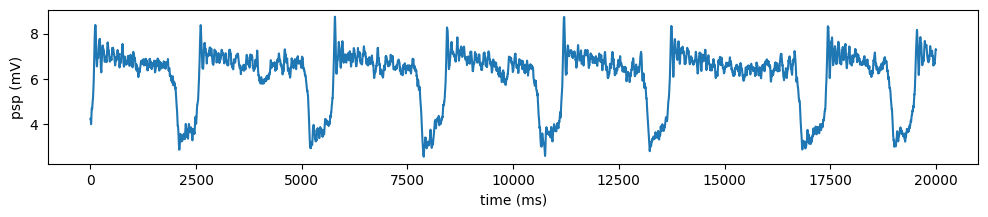

In [9]:
plt.figure(figsize=(12,2))
plt.plot(psp)
plt.xlabel('time (ms)')
plt.ylabel('psp (mV)')

# two coupled populations

Create two connected populations

In [7]:
conn2 = connectivity.Connectivity(centres=np.array([0]))
conn2.motif_all_to_all(number_of_regions=2)
conn2.tract_lengths*=0 # SET DISTANCE TO 0 TO ELIMINATE DELAYS
conn2.configure()

Run the simulation of two coupled populations

In [8]:
JR_params = JR_parameters()
JR_params.update({'g_ad':np.array([11.5]), 'J':np.array([112])})
exc_coupling = 10
jrm = JansenRit_SFA(**JR_params) 
param_dict= dict(model=jrm,
                connectivity= conn2,
                coupling=coupling.SigmoidalJansenRit(a=numpy.array([exc_coupling])), # global coupling 
                initial_conditions=np.random.uniform(0, 0.01, size=(1,jrm.nvar,conn2.number_of_regions,1)),
                integrator=integrators.HeunStochastic(dt=dt, noise=noise.Additive(nsig=sigma,noise_seed=1)),
                monitors=(monitors.Raw(),), simulation_length=23000)

sim = simulator.Simulator(**param_dict).configure()
# run it
(time, data), = sim.run()
transient=3000
time = time[transient:]
data = np.squeeze(data)[transient:]
psp = data[:, 1]-data[:, 2] # psp of pyramidal cell (epsp-ipsp, input from exc and inh interneuron)

Text(0, 0.5, 'psp (mV)')

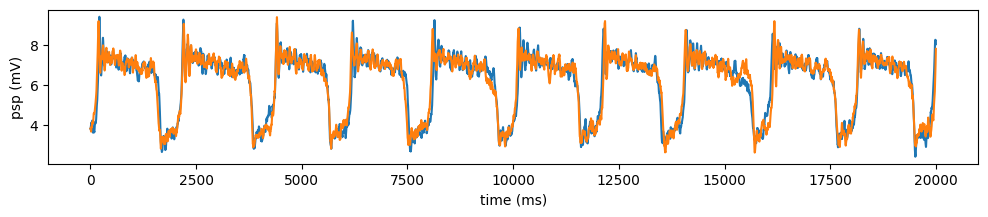

In [9]:
plt.figure(figsize=(12,2))
plt.plot(psp)
plt.xlabel('time (ms)')
plt.ylabel('psp (mV)')

# toy network

Create a small cortical motif with short and long-range connections

In [10]:
coords = np.array(([0,0],[-5,5], [5,5], [-5, -5], [5,-5], [50,0], [60,0],[70,0]))
def toy_net(coords, config=1):
    distance = np.zeros((coords.shape[0], coords.shape[0]))
    for node1 in range(coords.shape[0]):
          for node2 in range(coords.shape[0]):
                distance[node1, node2] = np.sqrt(np.sum((coords[node1,:] - coords[node2,:])**2, axis=0))
                distance[node1, node2] = np.sqrt(np.sum((coords[node1,:] - coords[node2,:])**2, axis=0))
    conn = connectivity.Connectivity(centres=coords)
    conn.motif_chain_directed(number_of_regions=len(coords))
    conn.tract_lengths = distance
    conn.weights*=0
    # input to node 0
    conn.weights[0,2]=1
    conn.weights[0,4]=1
    # input to node 1
    conn.weights[1,0]=1
    conn.weights[1,2]=1
    # input to node 2
    conn.weights[2,1]=1
    conn.weights[2,0]=1
    # input to node 3
    conn.weights[3,0]=1
    conn.weights[3,4]=1
    # input to node 4
    conn.weights[4,0]=1
    conn.weights[4,3]=1
    # input to node 5
    conn.weights[5,2]=1
    conn.weights[5,6]=1
    if config == 1: # used in Fig. 4A-C, 5A
        conn.weights[5,1] = 1
    elif config == 2: # used in Fig. 4D, 5B
        conn.weights[5,3] = 1
    else:
        raise ValueError(f"config should be 1 or 2, got {config}")
    # input to node 6
    conn.weights[6,5]=1
    conn.weights[6,7]=1
    # input to node 7
    conn.weights[7,6]=1

    for n in range(len(coords)): conn.weights[n]/=conn.weights[n].sum()
    conn.speed=np.array([4])
    conn.configure()
    return conn

conn_toy = toy_net(coords,config=1)

Define the lesion function: a lesion is implemented by removing all incoming and outgoing connections of the selected node

In [34]:
import copy
def lesion_conn(conn, lesion_nodes=[]):
    conn_lesioned = copy.deepcopy(conn)
    for node in lesion_nodes:
        conn_lesioned.weights[node, :] = 0
        conn_lesioned.weights[:, node] = 0
    return conn_lesioned

Run the simulation of the toy network

In [29]:
JR_params = JR_parameters()
JR_params.update({'g_ad':np.array([11.5]), 'J':np.array([112])})
jrm = JansenRit_SFA(**JR_params) 
exc_coupling = 30
les_node=0
intact_nodes = np.delete(np.arange(conn_toy.number_of_regions), les_node)
toy_les = lesion_conn(conn_toy, lesion_nodes=[les_node])
param_dict= dict(model=jrm,
                connectivity= toy_les, # conn_toy is the the control network (no down states)
                coupling=coupling.SigmoidalJansenRit(a=numpy.array([exc_coupling])), # global coupling 
                initial_conditions=np.random.uniform(0, 0.01, size=(1,jrm.nvar,conn_toy.number_of_regions,1)),
                integrator=integrators.HeunStochastic(dt=dt, noise=noise.Additive(nsig=sigma,noise_seed=1)),
                monitors=(monitors.Raw(),), simulation_length=23000)

sim = simulator.Simulator(**param_dict).configure()
# run it
(time, data), = sim.run()
transient=3000
time = time[transient:]
data = np.squeeze(data)[transient:]
psp = data[:, 1]-data[:, 2] # psp of pyramidal cell (epsp-ipsp, input from exc and inh interneuron)
psp = psp[:,intact_nodes] # remove lesion node

Text(0, 0.5, 'psp (mV)')

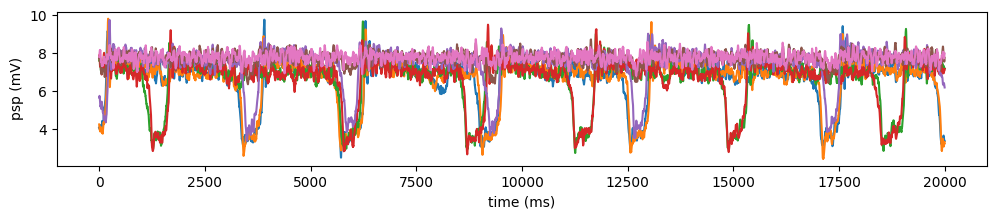

In [30]:
plt.figure(figsize=(12,2))
plt.plot(psp)
plt.xlabel('time (ms)')
plt.ylabel('psp (mV)')

# whole-brain network

In [14]:
from pymatreader import read_mat
from sklearn.metrics.pairwise import pairwise_distances

Download the file "SCmatrices88healthy.mat" from https://osf.io/yw5vf/files/6823g and place it in the AAL_conn folder to continue.

The SCs comes from https://www.nature.com/articles/s41597-022-01596-9. Please cite: "Škoch, A., Rehák Bučková, B., Mareš, J. et al. Human brain structural connectivity matrices–ready for modelling. Sci Data 9, 486 (2022). https://doi.org/10.1038/s41597-022-01596-9" if you use these data

In [33]:
SC = read_mat('AAL_conn\\SCmatrices88healthy.mat')['SCmatrices']
labels = pd.read_csv('AAL_conn\\AAL_regions.csv',delimiter=';' )
coords = pd.read_excel('AAL_conn\\AAL_coords.xls')
coords = coords.replace({'−': '-'}, regex=True)

Distribution of the number of connections across subjects

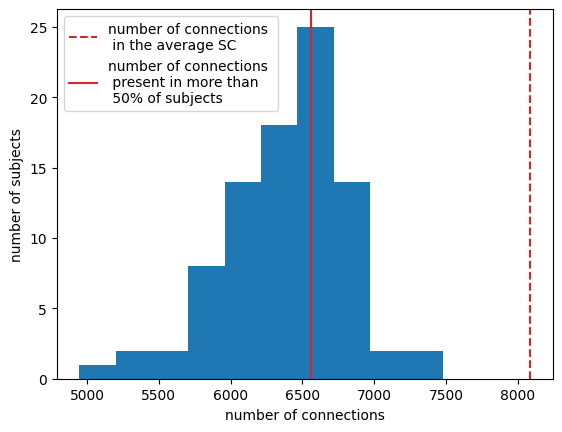

In [16]:
plt.figure()
plt.hist((SC>0)[:].sum((1,2)))
plt.xlabel('number of connections')
plt.ylabel('number of subjects')


# number of conn of the average connectivity 
plt.axvline(np.sum(SC.mean(0)>0), c='tab:red', ls='--', label='number of connections \n in the average SC')
# number of conn of the average connectivity where only the connections present in more than 50% of subj are retained
plt.axvline(np.sum((SC.mean(0)*((SC>0).sum(0)>(SC.shape[0]/2))) >0), c='tab:red', 
            label='number of connections \n present in more than \n 50% of subjects')
plt.legend()

Exclude subcortical regions and create a consesus SC (only connections present in more than 50% of the subjects are retained)

In [17]:
coords_cortex = []
labels_cortex = []
idx_cortex = []
roi_to_exc = ['Thal', 'Pall', 'Put', 'Caud', 'Amy']
for n in range(90):
    if not any(roi in coords.iloc[n]['abbreviation'] for roi in roi_to_exc):
        coords_cortex.append([float(coords.iloc[n][cc]) for cc in ['x','y','z']])
        labels_cortex.append(coords.iloc[n]['abbreviation'])              
        idx_cortex.append(n)
coords_cortex=np.array(coords_cortex)
labels_cortex=np.array(labels_cortex, dtype='<U128')
idx_cortex=np.array(idx_cortex)
#compute euclidean distance from the coords
dist_mat = pairwise_distances(coords_cortex, metric='euclidean')
#average connectivity where only the connections present in more than 50% of subj are retained, and exclude non cortical areas
conn_mat = (SC.mean(0)*((SC>0).sum(0)>(SC.shape[0]/2)))[idx_cortex][::,idx_cortex]
np.fill_diagonal(conn_mat,0)

Create a TVB Connectivity object from the SC data

In [18]:
conn_SC = connectivity.Connectivity(centres = coords_cortex)
conn_SC.weights = conn_mat
conn_SC.speed = np.r_[4.]
conn_SC.number_of_regions = conn_SC.weights.shape[0]
conn_SC.region_labels = labels_cortex
conn_SC.tract_lengths = dist_mat
# in-degree normalization
for n in range(conn_SC.number_of_regions): 
    if conn_SC.weights[n].sum()>0 : 
        conn_SC.weights[n,:]/=(np.sum(conn_SC.weights[n]))
conn_SC.configure()

Run the whole-brain simulation

In [31]:
JR_params = JR_parameters()
jrm = JansenRit_SFA(**JR_params) 
exc_coupling = 30
les_node=0
intact_nodes = np.delete(np.arange(conn_SC.number_of_regions), les_node)
SC_les = lesion_conn(conn_SC, lesion_nodes=[les_node])
param_dict= dict(model=jrm,
                connectivity= SC_les, # conn_SC is the the control network (no down states)
                coupling=coupling.SigmoidalJansenRit(a=numpy.array([exc_coupling])), # global coupling 
                initial_conditions=np.random.uniform(0, 0.01, size=(1,jrm.nvar,conn_SC.number_of_regions,1)),
                integrator=integrators.HeunStochastic(dt=dt, noise=noise.Additive(nsig=sigma,noise_seed=1)),
                monitors=(monitors.Raw(),), simulation_length=23000)

sim = simulator.Simulator(**param_dict).configure()
# run it
(time, data), = sim.run()
transient=3000
time = time[transient:]
data = np.squeeze(data)[transient:]
psp = data[:, 1]-data[:, 2] # psp of pyramidal cell (epsp-ipsp, input from exc and inh interneuron)
psp = psp[:,intact_nodes] # remove lesion node

Text(0, 0.5, 'psp (mV)')

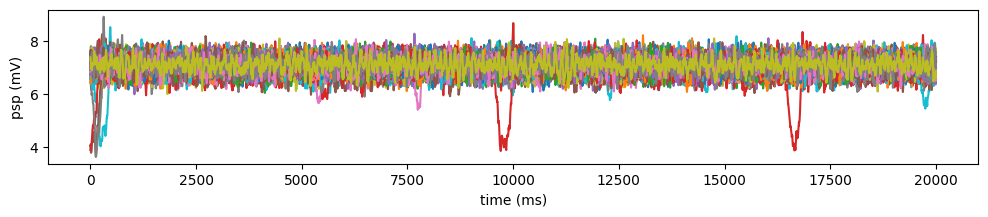

In [32]:
plt.figure(figsize=(12,2))
plt.plot(psp)
plt.xlabel('time (ms)')
plt.ylabel('psp (mV)')